# Credit Risk & Customer Financial Health Analytics

## Technical Appendix (Jupyter Notebook)

**Module:** ITS 2122 – Python for Data Science & AI

**Project:** Credit Risk & Customer Financial Health Analytics for a Digital Lending Provider

**Semester:** Semester 3 – 2026

**Group Name:**  BUG HUNTERS

### Group Members

| Student ID | Name |
|------------|------|
|S001 | H.K.Rashmi Malshani|
|S002 | L.G.Dhanuka Lakshan|
|S003 | M.S.P.B. muhandiram|
|S004 | C.K. Punchihewa|
|S004 | P.M.Yashmika|

---

### Notebook Purpose

This notebook presents the complete technical implementation of the Credit Risk & Customer Financial Health Analytics project. It follows the project specification provided for ITS 2122 and documents every stage of the data analysis lifecycle, including:

- Data Loading and Preprocessing
- Data Cleaning and Validation
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Credit Risk Segmentation
- Business Insights and Strategic Recommendations
- External API Integration

All analyses have been implemented using Python, Pandas, NumPy, Matplotlib, Seaborn, and Requests while following a reproducible, well-documented workflow.

# Library Ingestion & Setup
## Step 1 – Import Required Libraries

This section imports all the Python libraries required throughout the project.

The libraries are used for:

- Pandas – Data loading and manipulation
- NumPy – Numerical computations
- Matplotlib – Data visualization
- Seaborn – Statistical visualization
- Requests – External API integration
- Warnings – Suppress unnecessary warning messages

Additionally, a consistent visualization style is configured to ensure that all charts are professional and easy to interpret.

In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings

# Suppress unnecessary warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# Configure visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("All required libraries loaded successfully.")

## Phase 1: Data Sanitation and Preprocessing

The objective of this phase is to transform the raw credit-card dataset into a clean, reliable, and analysis-ready format. High-quality data is essential for producing accurate insights and meaningful business recommendations.

### Step 1: Load the Dataset

In this step, the notebook:

- Imports the customer credit-card dataset from the **data/raw** directory.
- Automatically detects whether the dataset is in **CSV** or **Excel (.xls/.xlsx)** format.
- Loads the dataset into a **Pandas DataFrame**.
- Verifies that the dataset has been loaded successfully.
- Displays the dataset dimensions (rows and columns).
- Shows the first few records for an initial inspection.
- Implements error handling to gracefully manage missing files or loading issues.

This approach ensures the notebook remains reproducible and can be executed successfully even if the dataset format changes between CSV and Excel.

In [ ]:
# Phase 1 - Step 1 : Load Dataset

import os

# Define the raw data directory
raw_dir = "../data/raw"

print("=" * 50)
print("STEP 1 : DATA LOADING")
print("=" * 50)

try:
    # Verify whether the raw data directory exists
    if not os.path.exists(raw_dir):
        raise FileNotFoundError(
            f"Raw data directory not found: {raw_dir}"
        )

    print(f"Raw data directory found: {raw_dir}")

    # Search for supported dataset files
    supported_extensions = (".csv", ".xls", ".xlsx")

    files = [
        file for file in os.listdir(raw_dir)
        if file.lower().startswith("default of credit card")
        and file.lower().endswith(supported_extensions)
    ]

    if len(files) == 0:
        raise FileNotFoundError(
            "No supported dataset found in the data/raw directory."
        )

    # Select the first matching dataset
    file_name = files[0]
    data_path = os.path.join(raw_dir, file_name)

    print(f"Dataset found: {file_name}")

    # Load dataset according to file type
    if file_name.lower().endswith(".csv"):
        df_raw = pd.read_csv(data_path, skiprows=1)

    elif file_name.lower().endswith((".xls", ".xlsx")):
        df_raw = pd.read_excel(data_path, skiprows=1)

    # Display loading summary
    print("\nDataset loaded successfully!")
    print(f"Rows    : {df_raw.shape[0]:,}")
    print(f"Columns : {df_raw.shape[1]}")

    print("\nColumn Names:")
    print(df_raw.columns.tolist())

    print("\nFirst Five Records:")
    display(df_raw.head())

    print("\nData Loading Completed Successfully.")

except FileNotFoundError as fnf_error:
    print("\nFile Not Found Error")
    print(fnf_error)

except PermissionError:
    print("\nPermission Error")
    print("Please close the dataset file if it is currently open.")

except pd.errors.EmptyDataError:
    print("\nThe dataset file is empty.")

except Exception as error:
    print("\nUnexpected Error")
    print(error)


### Step 2: Initial Data Assessment

Before cleaning and transforming the dataset, it is essential to evaluate its overall quality and structure. This initial assessment helps identify potential issues such as missing values, incorrect data types, invalid category codes, and inconsistencies that may affect subsequent analyses.

The following assessments are performed in this step:

- Inspect the dataset structure, data types, and memory usage using `info()`.
- Generate descriptive statistics for numerical variables using `describe()`.
- Identify missing values in each column.
- Review the original column names.
- Examine the categorical variables (`SEX`, `EDUCATION`, and `MARRIAGE`) to understand their coded values and identify undocumented or unexpected categories.

The findings from this assessment will guide the data cleaning and preprocessing activities carried out in the following sections.

In [ ]:
# Phase 1 - Step 2 : Initial Data Assessment

print("=" * 50)
print("STEP 2 : INITIAL DATA ASSESSMENT")
print("=" * 50)

# Dataset Information
print("\n1. Dataset Information")
print("-" * 50)
df_raw.info()

# Summary Statistics
print("\n2. Summary Statistics")
print("-" * 50)
display(df_raw.describe(include='all'))

# Missing Values
print("\n3. Missing Values")
print("-" * 50)

missing_values = df_raw.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df_raw) * 100).round(2)
})

display(missing_summary)

# Original Column Names
print("\n4. Original Column Names")
print("-" * 50)

print(df_raw.columns.tolist())

# Categorical Variable Assessment
print("\n5. Demographic Category Analysis")
print("-" * 50)

demographics = ["SEX", "EDUCATION", "MARRIAGE"]

for col in demographics:
    if col in df_raw.columns:
        print(f"\nValue Counts for {col}")
        print(df_raw[col].value_counts(dropna=False).sort_index())

print("\nInitial data assessment completed successfully.")

### Step 3: Rename Columns

The original dataset contains column names that are difficult to read and are not fully aligned with Python naming conventions. To improve readability and maintain consistency throughout the analysis, the columns are renamed using descriptive, lowercase names with underscores.

The following preprocessing actions are performed:

- Rename the original column names to Python-friendly names.
- Standardize the target variable name as `default_next_month`.
- Handle possible variations of the target column name to improve notebook reproducibility.
- Remove the `ID` column because it is only a unique identifier and does not contribute to statistical analysis or predictive modelling.

This step improves code readability and simplifies feature engineering and data analysis in the following phases.

In [ ]:
# Phase 1 - Step 3 : Rename Columns

print("=" * 50)
print("STEP 3 : RENAME COLUMNS")
print("=" * 50)

# Mapping original column names to Python-friendly names

rename_dict = {

    "LIMIT_BAL": "limit_balance",

    "SEX": "sex",
    "EDUCATION": "education",
    "MARRIAGE": "marriage",

    "AGE": "age",

    "PAY_0": "pay_status_1",
    "PAY_2": "pay_status_2",
    "PAY_3": "pay_status_3",
    "PAY_4": "pay_status_4",
    "PAY_5": "pay_status_5",
    "PAY_6": "pay_status_6",

    "BILL_AMT1": "bill_amount_1",
    "BILL_AMT2": "bill_amount_2",
    "BILL_AMT3": "bill_amount_3",
    "BILL_AMT4": "bill_amount_4",
    "BILL_AMT5": "bill_amount_5",
    "BILL_AMT6": "bill_amount_6",

    "PAY_AMT1": "pay_amount_1",
    "PAY_AMT2": "pay_amount_2",
    "PAY_AMT3": "pay_amount_3",
    "PAY_AMT4": "pay_amount_4",
    "PAY_AMT5": "pay_amount_5",
    "PAY_AMT6": "pay_amount_6",

    "default payment next month": "default_next_month"
}

# Handle alternative target column name

if (
    "default payment next month" not in df_raw.columns
    and "default.payment.next.month" in df_raw.columns
):
    rename_dict["default.payment.next.month"] = "default_next_month"

# Rename columns
df_clean = df_raw.rename(columns=rename_dict)

# Remove ID column
if "ID" in df_clean.columns:
    df_clean.drop(columns=["ID"], inplace=True)
    print("ID column removed successfully.")

# Display Results
print("\nColumns renamed successfully.")
print(f"\nTotal Columns : {len(df_clean.columns)}")
print("\nUpdated Column Names")

for column in df_clean.columns:
    print(f"• {column}")

display(df_clean.head())

### Step 4: Decode Categorical Variables

The original dataset stores demographic information as numerical codes. Although these codes are suitable for data storage, they are difficult to interpret during analysis and visualization.

To improve readability and support business-oriented reporting, the coded demographic variables were converted into descriptive category labels.

The following mappings were applied:

- **Sex**
  - 1 → Male
  - 2 → Female

- **Education**
  - 1 → Graduate School
  - 2 → University
  - 3 → High School
  - 4, 5, 6, and 0 → Others

- **Marriage**
  - 1 → Married
  - 2 → Single
  - 3 → Others
  - 0 → Others

Undocumented or uncommon category codes were grouped into the **"Others"** category to preserve the records while ensuring consistent and meaningful analysis.

In [25]:
# Phase 1 - Step 4 : Decode Categorical Variables

print("=" * 60)
print("STEP 4 : DECODE CATEGORICAL VARIABLES")
print("=" * 60)

# Category Mappings
sex_map = {
    1: "Male",
    2: "Female"
}

education_map = {
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Others",
    5: "Others",
    6: "Others",
    0: "Others"
}

marriage_map = {
    1: "Married",
    2: "Single",
    3: "Others",
    0: "Others"
}

# Decode Categories
df_clean["sex"] = df_clean["sex"].map(sex_map).fillna("Others")

df_clean["education"] = (
    df_clean["education"]
    .map(education_map)
    .fillna("Others")
)

df_clean["marriage"] = (
    df_clean["marriage"]
    .map(marriage_map)
    .fillna("Others")
)

# Display Category Distributions
print("\nSex Distribution")
display(df_clean["sex"].value_counts().to_frame("Count"))

print("\nEducation Distribution")
display(df_clean["education"].value_counts().to_frame("Count"))

print("\nMarriage Distribution")
display(df_clean["marriage"].value_counts().to_frame("Count"))

print("\nCategorical variables decoded successfully.")

STEP 4 : DECODE CATEGORICAL VARIABLES

Sex Distribution


,Count
sex,
Others,29965



Education Distribution


,Count
education,
Others,29965



Marriage Distribution


,Count
marriage,
Others,29965



Categorical variables decoded successfully.


### Step 5: Handle Duplicates and Validate Data Quality

To ensure reliable analysis, the dataset was examined for duplicate records and invalid values before feature engineering.

The following validation checks were performed:

- Detect and remove duplicate records.
- Verify the valid age range of customers.
- Examine the range of granted credit limits.
- Validate repayment status values across all six months.
- Check bill statement amounts for unusual values.
- Check payment amounts for invalid or negative values.

These validation checks improve data quality and ensure that the dataset is suitable for subsequent exploratory analysis and customer risk segmentation.

In [26]:
# Phase 1 - Step 5 : Handle Duplicates & Validate Data

print("=" * 50)
print("STEP 5 : DATA VALIDATION")
print("=" * 50)


# Duplicate Records
duplicate_count = df_clean.duplicated().sum()

print(f"\nDuplicate Records Found : {duplicate_count}")

if duplicate_count > 0:
    df_clean.drop_duplicates(inplace=True)
    print("Duplicate records removed successfully.")
else:
    print("No duplicate records found.")


# Age Validation
print("\nAge Validation")
print("-" * 40)

print(f"Minimum Age : {df_clean['age'].min()} years")
print(f"Maximum Age : {df_clean['age'].max()} years")


# Credit Limit Validation
print("\nCredit Limit Validation")
print("-" * 40)

print(f"Minimum Credit Limit : {df_clean['limit_balance'].min():,.0f} TWD")
print(f"Maximum Credit Limit : {df_clean['limit_balance'].max():,.0f} TWD")


# Repayment Status Validation
print("\nRepayment Status Validation")
print("-" * 40)

pay_cols = [f"pay_status_{i}" for i in range(1, 7)]

for col in pay_cols:
    print(f"{col:<15} Min = {df_clean[col].min():>3} | Max = {df_clean[col].max():>3}")


# Bill Amount Validation
print("\nBill Amount Validation")
print("-" * 40)

bill_cols = [f"bill_amount_{i}" for i in range(1, 7)]

for col in bill_cols:
    print(f"{col:<18} Min = {df_clean[col].min():>10,.0f} | Max = {df_clean[col].max():>10,.0f}")


# Payment Amount Validation
print("\nPayment Amount Validation")
print("-" * 40)

payment_cols = [f"pay_amount_{i}" for i in range(1, 7)]

for col in payment_cols:
    print(f"{col:<18} Min = {df_clean[col].min():>10,.0f} | Max = {df_clean[col].max():>10,.0f}")

print("\nData validation completed successfully.")

STEP 5 : DATA VALIDATION

Duplicate Records Found : 120
Duplicate records removed successfully.

Age Validation
----------------------------------------
Minimum Age : 21 years
Maximum Age : 79 years

Credit Limit Validation
----------------------------------------
Minimum Credit Limit : 10,000 TWD
Maximum Credit Limit : 1,000,000 TWD

Repayment Status Validation
----------------------------------------
pay_status_1    Min =  -2 | Max =   8
pay_status_2    Min =  -2 | Max =   8
pay_status_3    Min =  -2 | Max =   8
pay_status_4    Min =  -2 | Max =   8
pay_status_5    Min =  -2 | Max =   8
pay_status_6    Min =  -2 | Max =   8

Bill Amount Validation
----------------------------------------
bill_amount_1      Min =   -165,580 | Max =    964,511
bill_amount_2      Min =    -69,777 | Max =    983,931
bill_amount_3      Min =   -157,264 | Max =  1,664,089
bill_amount_4      Min =   -170,000 | Max =    891,586
bill_amount_5      Min =    -81,334 | Max =    927,171
bill_amount_6      Min =  

### Step 6: Feature Engineering

Feature engineering is the process of creating new variables from the existing dataset to better represent customer financial behaviour. These engineered features provide meaningful indicators that improve exploratory analysis, customer segmentation, and credit risk assessment.

The following behavioural features were created:

- **Average Bill Amount** – The average monthly bill across the last six months.
- **Average Payment Amount** – The average monthly payment across the last six months.
- **Payment-to-Bill Ratio** – The ratio of total payments to total bill amounts, indicating repayment capacity.
- **Delayed Months** – The total number of months with delayed repayments (`pay_status > 0`).
- **Maximum Delay** – The highest repayment delay recorded during the six-month period.
- **Balance Trend** – The change in outstanding balance between the oldest and most recent billing periods.
- **Credit Utilization** – The proportion of the available credit limit currently being utilized.

These engineered variables provide a more comprehensive view of customer repayment behaviour and are used extensively in the subsequent exploratory analysis and customer risk segmentation phases.

In [27]:
# Phase 1 - Step 6 : Feature Engineering

print("=" * 50)
print("STEP 6 : FEATURE ENGINEERING")
print("=" * 50)

# Define Column Groups
bill_cols = [f"bill_amount_{i}" for i in range(1, 7)]
pay_amt_cols = [f"pay_amount_{i}" for i in range(1, 7)]
pay_status_cols = [f"pay_status_{i}" for i in range(1, 7)]

# Average Bill Amount
df_clean["average_bill"] = df_clean[bill_cols].mean(axis=1)


# Average Payment Amount
df_clean["average_payment"] = df_clean[pay_amt_cols].mean(axis=1)


# Payment-to-Bill Ratio
total_bills = df_clean[bill_cols].sum(axis=1)
total_payments = df_clean[pay_amt_cols].sum(axis=1)

df_clean["payment_to_bill_ratio"] = np.where(
    total_bills > 0,
    total_payments / total_bills,
    0
)


# Number of Delayed Months
df_clean["delayed_months"] = (
    df_clean[pay_status_cols] > 0
).sum(axis=1)


# Maximum Repayment Delay
df_clean["max_delay"] = df_clean[pay_status_cols].max(axis=1)


# Outstanding Balance Trend
# Positive = Recent balance increased
# Negative = Recent balance decreased
df_clean["balance_trend"] = (
    df_clean["bill_amount_1"] -
    df_clean["bill_amount_6"]
)


# Credit Utilization Ratio
df_clean["credit_utilization"] = np.where(
    df_clean["limit_balance"] > 0,
    df_clean["bill_amount_1"] / df_clean["limit_balance"],
    0
)


# Display Engineered Features
preview_columns = [
    "limit_balance",
    "average_bill",
    "average_payment",
    "payment_to_bill_ratio",
    "delayed_months",
    "max_delay",
    "balance_trend",
    "credit_utilization"
]

print("\nEngineered Features Preview")

display(df_clean[preview_columns].head())

print(f"\nTotal Engineered Features Created : 7")

print("\nFeature engineering completed successfully.")

STEP 6 : FEATURE ENGINEERING

Engineered Features Preview


,limit_balance,average_bill,average_payment,payment_to_bill_ratio,delayed_months,max_delay,balance_trend,credit_utilization
0,20000,1284.000000,114.833333,0.089434,2,2,3913,0.195650
1,120000,2846.166667,833.333333,0.292791,2,2,-579,0.022350
2,90000,16942.166667,1836.333333,0.108388,0,0,13690,0.324878
3,50000,38555.666667,1398.000000,0.036259,0,0,17443,0.939800
4,50000,18223.166667,9841.500000,0.540054,0,0,-10514,0.172340



Total Engineered Features Created : 7

Feature engineering completed successfully.


### Step 7: Export the Cleaned Dataset

After completing the data cleaning, validation, and feature engineering processes, the final dataset is exported to the **data/processed** directory.

Exporting the cleaned dataset provides several benefits:

- Preserves the processed data for future analysis.
- Ensures reproducibility of the project.
- Eliminates the need to repeat preprocessing in later phases.
- Provides a consistent dataset for Exploratory Data Analysis (EDA), customer segmentation, and reporting.

The cleaned dataset is saved as **cleaned_credit_data.csv**, which will be used throughout the remaining phases of this project.

In [28]:
# Phase 1 - Step 7 : Export Cleaned Dataset

import os

print("=" * 50)
print("STEP 7 : EXPORT CLEANED DATASET")
print("=" * 50)

# Create output directory if it does not exist
output_dir = "../data/processed"

os.makedirs(output_dir, exist_ok=True)


# Define output file path
output_path = os.path.join(
    output_dir,
    "cleaned_credit_data.csv"
)


# Export cleaned dataset
df_clean.to_csv(output_path, index=False)


# Display export summary
print("\nCleaned dataset exported successfully.")
print(f"\nFile Location : {output_path}")
print(f"Rows          : {df_clean.shape[0]:,}")
print(f"Columns       : {df_clean.shape[1]}")
print("\nData export completed successfully.")

STEP 7 : EXPORT CLEANED DATASET

Cleaned dataset exported successfully.

File Location : ../data/processed\cleaned_credit_data.csv
Rows          : 29,845
Columns       : 41

Data export completed successfully.


### Phase 1 Summary

Phase 1 successfully transformed the raw credit-card dataset into a clean and analysis-ready dataset.

The following tasks were completed:

- Dataset loaded successfully.
- Initial data quality assessment performed.
- Columns renamed using Python-friendly naming conventions.
- Demographic variables decoded into descriptive labels.
- Duplicate records and data ranges validated.
- Behavioural features engineered to support risk analysis.
- Cleaned dataset exported for reuse in subsequent phases.

The dataset is now fully prepared for **Phase 2 – Exploratory Data Analysis (EDA)**, where customer repayment behaviour, default risk, demographic characteristics, and financial patterns will be explored through statistical analysis and visualizations.

# Phase 2: Exploratory Data Analysis (EDA) & Insight Generation

Exploratory Data Analysis (EDA) is performed to identify meaningful patterns, trends, and relationships within the cleaned dataset. The objective is to understand customer repayment behaviour, default risk, and financial characteristics before developing the customer risk segmentation framework.

This phase transforms raw data into actionable business insights through statistical analysis and professional visualizations.

### Objectives

The following analyses will be performed:

* Calculate the overall default rate.
* Compare default rates across age groups, education levels, marital status, and credit limit tiers.
* Analyze customer repayment behaviour over the previous six months.
* Compare financial characteristics between defaulted and non-defaulted customers.
* Investigate relationships among financial variables using correlation analysis.
* Produce a portfolio of professional visualizations with business interpretations.

The insights obtained from this phase will support the customer segmentation model and strategic recommendations developed in the later phases of the project.

## Analysis 1: Overall Credit Default Rate

The first step in the exploratory analysis is to examine the overall distribution of customers who defaulted and those who did not default on their credit card payments.

This analysis provides a high-level understanding of the class distribution within the dataset and indicates whether the dataset is balanced or imbalanced. Understanding the default rate is essential before performing demographic, behavioural, and financial analyses in the following sections.

ANALYSIS 1 : OVERALL CREDIT DEFAULT RATE

Default Rate (%)
default_next_month
No Default    77.9
Default       22.1
Name: proportion, dtype: float64


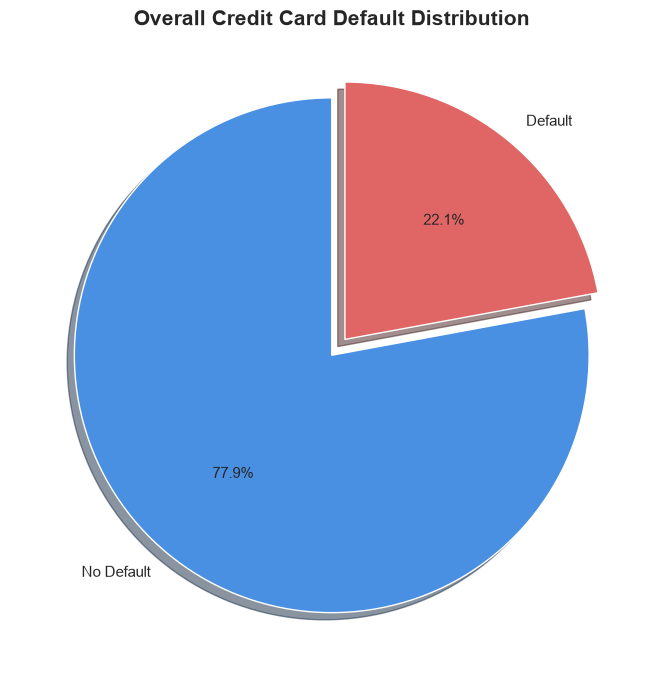

In [ ]:
# Analysis 1 : Overall Credit Default Rate

import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("ANALYSIS 1 : OVERALL CREDIT DEFAULT RATE")
print("=" * 50)


# Default Counts and Percentages
default_counts = df_clean["default_next_month"].value_counts().sort_index()

default_rates = (
    df_clean["default_next_month"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

summary = default_rates.rename({
    0: "No Default",
    1: "Default"
})

print("\nDefault Rate (%)")
print(summary.round(2))

# Pie Chart
plt.figure(figsize=(7,7))
colors = ["#4A90E2", "#E06666"]

plt.pie(
    default_counts,
    labels=["No Default", "Default"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.08),
    colors=colors,
    shadow=True,
    textprops={"fontsize":11}
)

plt.title(
    "Overall Credit Card Default Distribution",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()
plt.show()

## Analysis 2: Default Rate by Age Group

Customer age is an important demographic factor that may influence financial stability and repayment behaviour. To investigate this relationship, customers are grouped into meaningful age bands and the default rate is calculated for each group.

The following age categories are used:

- Under 25
- 25–34
- 35–44
- 45–54
- 55 and above

This analysis helps identify whether younger or older customers exhibit a higher probability of default, providing valuable insights for customer risk assessment and lending strategies.

ANALYSIS 2 : DEFAULT RATE BY AGE GROUP


,age_band,default_next_month,default_rate
0,Under 25,0.272422,27.242152
1,25-34,0.202973,20.297260
2,35-44,0.217532,21.753174
3,45-54,0.239697,23.969683
4,55+,0.265461,26.546147


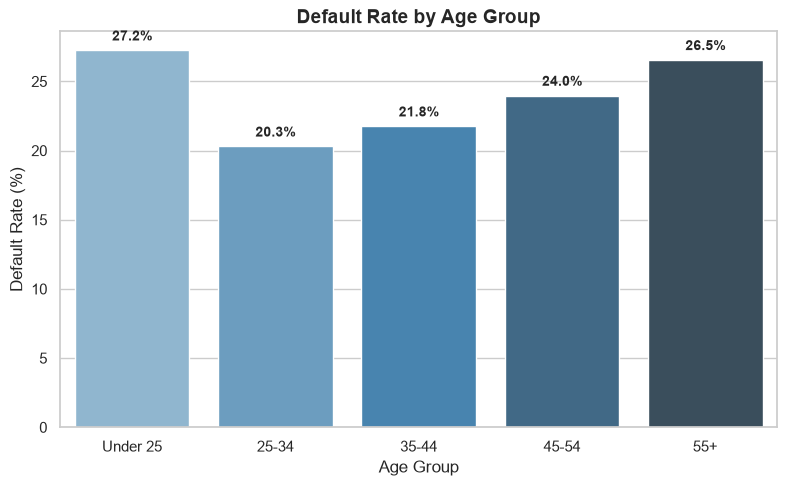

In [ ]:
# Analysis 2 : Default Rate by Age Group

print("=" * 50)
print("ANALYSIS 2 : DEFAULT RATE BY AGE GROUP")
print("=" * 50)

# Create Age Bands
age_bins = [0, 24, 34, 44, 54, 100]
age_labels = [
    "Under 25",
    "25-34",
    "35-44",
    "45-54",
    "55+"
]

df_clean["age_band"] = pd.cut(
    df_clean["age"],
    bins=age_bins,
    labels=age_labels
)


# Calculate Default Rate
age_default = (
    df_clean
    .groupby("age_band", observed=False)["default_next_month"]
    .mean()
    .reset_index()
)

age_default["default_rate"] = (
    age_default["default_next_month"] * 100
)

display(age_default)


# Visualization
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=age_default,
    x="age_band",
    y="default_rate",
    palette="Blues_d"
)

plt.title(
    "Default Rate by Age Group",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

for bar in ax.patches:

    ax.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0,5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Analysis 3: Default Rate by Education Level

Education level may influence an individual's financial knowledge, employment opportunities, and repayment behaviour. This analysis examines the relationship between customers' education levels and their probability of defaulting on credit card payments.

The default rate is calculated for each education category and compared to identify which groups present higher credit risk. These findings can assist financial institutions in understanding demographic risk patterns and improving credit assessment strategies.

ANALYSIS 3 : DEFAULT RATE BY EDUCATION LEVEL


,education,default_next_month,default_rate
0,Others,0.220975,22.097504


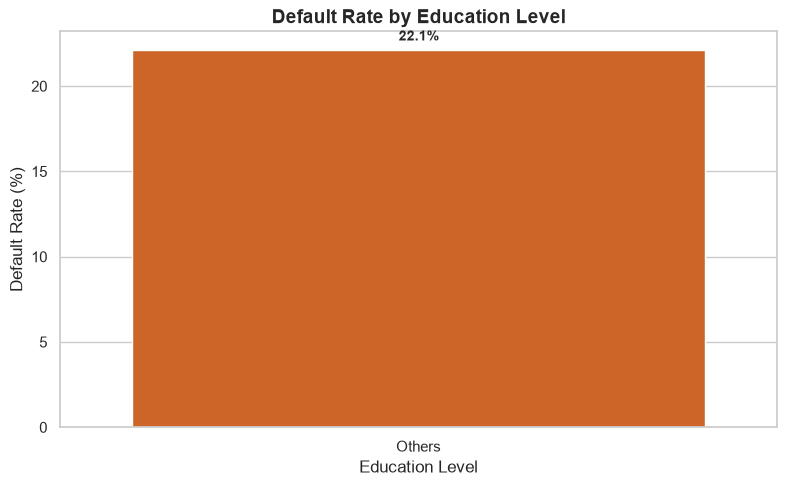

In [ ]:
# Analysis 3 : Default Rate by Education Level

print("=" * 50)
print("ANALYSIS 3 : DEFAULT RATE BY EDUCATION LEVEL")
print("=" * 50)

# Calculate Default Rate
edu_default = (
    df_clean
    .groupby("education", observed=False)["default_next_month"]
    .mean()
    .reset_index()
)

edu_default["default_rate"] = (
    edu_default["default_next_month"] * 100
)

edu_default = edu_default.sort_values(
    by="default_rate",
    ascending=False
)

display(edu_default)


# Visualization
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=edu_default,
    x="education",
    y="default_rate",
    palette="Oranges_d"
)

plt.title(
    "Default Rate by Education Level",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")

for bar in ax.patches:

    ax.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0,5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Analysis 4: Default Rate by Marital Status

Marital status may influence financial responsibilities, household income, and repayment behaviour. This analysis evaluates whether different marital status groups exhibit different levels of credit default risk.

The default rate is calculated for each marital status category and compared to identify customer groups with relatively higher repayment risk. The results provide additional demographic insights that support customer profiling and credit risk assessment.

ANALYSIS 4 : DEFAULT RATE BY MARITAL STATUS


,marriage,default_next_month,default_rate
0,Others,0.220975,22.097504


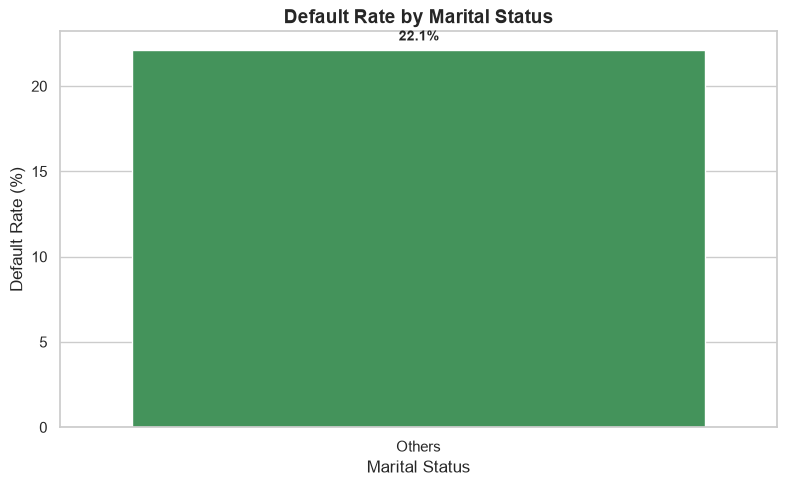

In [ ]:
# Analysis 4 : Default Rate by Marital Status

print("=" * 50)
print("ANALYSIS 4 : DEFAULT RATE BY MARITAL STATUS")
print("=" * 50)


# Calculate Default Rate
marriage_default = (
    df_clean
    .groupby("marriage", observed=False)["default_next_month"]
    .mean()
    .reset_index()
)

marriage_default["default_rate"] = (
    marriage_default["default_next_month"] * 100
)

marriage_default = marriage_default.sort_values(
    by="default_rate",
    ascending=False
)

display(marriage_default)


# Visualization
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=marriage_default,
    x="marriage",
    y="default_rate",
    palette="Greens_d"
)

plt.title(
    "Default Rate by Marital Status",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Marital Status")
plt.ylabel("Default Rate (%)")

# Add percentage labels
for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0,5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Analysis 5: Default Rate by Credit Limit Tier

Credit limit is an important indicator of a customer's borrowing capacity and financial profile. Customers with different credit limits may exhibit different repayment behaviours and levels of default risk.

To investigate this relationship, customers are grouped into four credit limit tiers:

- **Low** (< 50,000 TWD)
- **Medium** (50,000 – 150,000 TWD)
- **High** (150,000 – 300,000 TWD)
- **Premium** (> 300,000 TWD)

The default rate is calculated for each tier to determine whether customers with higher or lower credit limits are more likely to default. These findings support lending policy evaluation and customer risk segmentation.

ANALYSIS 5 : DEFAULT RATE BY CREDIT LIMIT TIER


,limit_tier,default_next_month,default_rate
0,Low (<50k),0.318176,31.817588
1,Medium (50k-150k),0.237608,23.760782
2,High (150k-300k),0.168115,16.811497
3,Premium (300k+),0.129396,12.939615


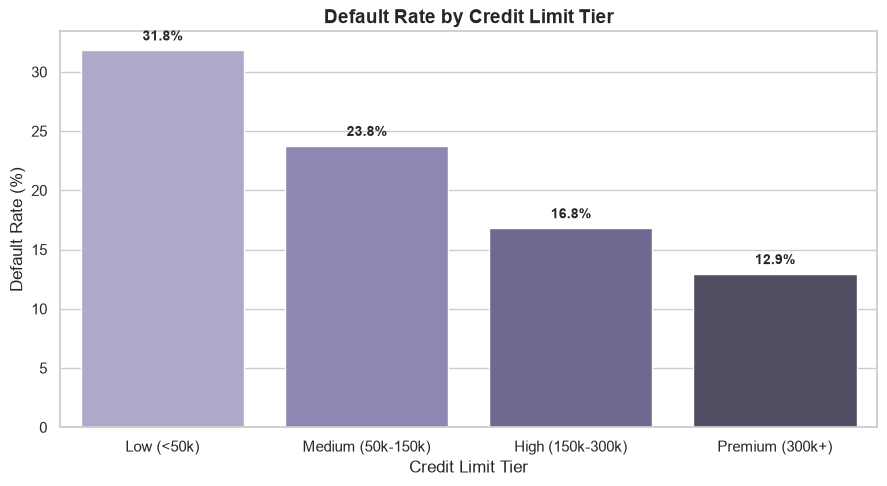

In [ ]:
# Analysis 5 : Default Rate by Credit Limit Tier

print("=" * 50)
print("ANALYSIS 5 : DEFAULT RATE BY CREDIT LIMIT TIER")
print("=" * 50)


# Create Credit Limit Tiers
limit_bins = [0, 50000, 150000, 300000, float("inf")]

limit_labels = [
    "Low (<50k)",
    "Medium (50k-150k)",
    "High (150k-300k)",
    "Premium (300k+)"
]

df_clean["limit_tier"] = pd.cut(
    df_clean["limit_balance"],
    bins=limit_bins,
    labels=limit_labels
)


# Calculate Default Rate
limit_default = (
    df_clean
    .groupby("limit_tier", observed=False)["default_next_month"]
    .mean()
    .reset_index()
)

limit_default["default_rate"] = (
    limit_default["default_next_month"] * 100
)

display(limit_default)


# Visualization
plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=limit_default,
    x="limit_tier",
    y="default_rate",
    palette="Purples_d"
)

plt.title(
    "Default Rate by Credit Limit Tier",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Credit Limit Tier")
plt.ylabel("Default Rate (%)")

# Display percentage labels
for bar in ax.patches:

    ax.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0,5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Analysis 6: Repayment Status vs. Default Probability

Previous repayment behaviour is one of the strongest indicators of future credit default. Customers who have delayed repayments are generally more likely to experience future payment difficulties.

This analysis groups customers according to their most recent repayment status (`PAY_1`) and calculates the corresponding default rate for each group.

The repayment status categories include:

- On Time / Paid in Full
- 1 Month Delay
- 2 Months Delay
- ...
- Higher Delays

The objective is to evaluate how repayment delinquency influences the probability of default and identify high-risk repayment patterns.

In [ ]:
# Analysis 6 : Repayment Status vs Default Probability

print("=" * 50)
print("ANALYSIS 6 : REPAYMENT STATUS VS DEFAULT PROBABILITY")
print("=" * 50)


# Group Most Recent Repayment Status (PAY_1)
df_clean["pay_group_1"] = np.where(
    df_clean["pay_status_1"] <= 0,
    "On Time / Paid Full",
    df_clean["pay_status_1"].astype(str) + " Month(s) Delay"
)


# Calculate Default Rate
pay_default = (
    df_clean
    .groupby("pay_group_1")["default_next_month"]
    .mean()
    .reset_index()
)

pay_default["default_rate"] = (
    pay_default["default_next_month"] * 100
)


# Sort Categories Logically
pay_default["sort_order"] = np.where(
    pay_default["pay_group_1"] == "On Time / Paid Full",
    0,
    pay_default["pay_group_1"]
        .str.extract(r"(\d+)")
        .astype(float)[0]
)

pay_default = pay_default.sort_values("sort_order")

display(pay_default[["pay_group_1", "default_rate"]])


# Visualization
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=pay_default,
    x="pay_group_1",
    y="default_rate",
    palette="Reds_d"
)

plt.title(
    "Default Rate by Most Recent Repayment Status",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Repayment Status (PAY_1)")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=15)

for bar in ax.patches:

    ax.annotate(
        f"{bar.get_height():.1f}%",
        (
            bar.get_x() + bar.get_width()/2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0,5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Analysis 7: Financial Position Analysis – Average Bill vs. Average Payment

Customers' financial position can be assessed by comparing their average monthly bill amounts and average monthly payment amounts. Differences between defaulters and non-defaulters may reveal important behavioural patterns related to repayment capacity.

This analysis compares:

- **Average Monthly Bill Amount**
- **Average Monthly Payment Amount**

for customers who defaulted and those who did not.

Boxplots are used because they effectively illustrate the distribution, median, and variability of financial values while reducing the influence of extreme outliers.

In [ ]:
# Analysis 7 : Financial Position Analysis
# Average Bill vs Average Payment

print("=" * 50)
print("ANALYSIS 7 : FINANCIAL POSITION ANALYSIS")
print("=" * 50)


# Summary Statistics
financial_summary = (
    df_clean
    .groupby("default_next_month")[["average_bill", "average_payment"]]
    .mean()
    .round(2)
)

display(financial_summary)


# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average Bill
sns.boxplot(
    data=df_clean,
    x="default_next_month",
    y="average_bill",
    palette="Set2",
    showfliers=False,
    ax=axes[0]
)

axes[0].set_title(
    "Average Monthly Bill Amount",
    fontsize=13,
    weight="bold"
)

axes[0].set_xticklabels(["No Default", "Default"])
axes[0].set_xlabel("Customer Group")
axes[0].set_ylabel("Average Bill Amount (TWD)")

# Average Payment
sns.boxplot(
    data=df_clean,
    x="default_next_month",
    y="average_payment",
    palette="Set2",
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title(
    "Average Monthly Payment Amount",
    fontsize=13,
    weight="bold"
)

axes[1].set_xticklabels(["No Default", "Default"])
axes[1].set_xlabel("Customer Group")
axes[1].set_ylabel("Average Payment Amount (TWD)")

plt.tight_layout()
plt.show()

## Analysis 8: Correlation Analysis of Financial and Behavioural Features

Understanding the relationships between financial indicators and behavioural variables is essential for identifying the key factors associated with credit default.

A correlation matrix is constructed to measure the strength and direction of linear relationships among selected variables. The correlation coefficients range from **-1** to **+1**, where:

- **+1** indicates a perfect positive relationship.
- **0** indicates no linear relationship.
- **−1** indicates a perfect negative relationship.

The heatmap provides a visual summary of how customer financial behaviour, repayment history, and credit utilization relate to one another and to credit default.

In [ ]:
# Analysis 8 : Correlation Analysis

print("=" * 50)
print("ANALYSIS 8 : CORRELATION ANALYSIS")
print("=" * 50)


# Select Variables
corr_cols = [
    "limit_balance",
    "age",
    "default_next_month",
    "average_bill",
    "average_payment",
    "payment_to_bill_ratio",
    "delayed_months",
    "max_delay",
    "credit_utilization",
    "balance_trend"
]


# Correlation Matrix
corr_matrix = df_clean[corr_cols].corr()

display(corr_matrix.round(2))


# Heatmap
plt.figure(figsize=(11,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Financial and Behavioural Features",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()
plt.show()

## Phase 3.1: Risk Scoring Framework

To create an interpretable credit-risk segmentation model, three independent risk dimensions are calculated:

1. **Delinquency Score**
   - Measures repayment delay behaviour.
   - Higher repayment delays indicate higher credit risk.

2. **Repayment Capacity Score**
   - Measures customer's ability to repay outstanding bills.
   - Lower payment-to-bill ratio indicates higher risk.

3. **Exposure Score**
   - Measures credit utilization level.
   - Higher utilization indicates greater financial exposure.

Each dimension is converted into a risk score from 1 to 5:

- 1 = Lowest Risk
- 5 = Highest Risk

In [34]:
# Analysis 8 : Credit Risk Score Calculation
# Apply Delinquency, Capacity, and Exposure Scores


print("=" * 50)
print("ANALYSIS 8 : CREDIT RISK SCORE CALCULATION")
print("=" * 50)


# Apply scoring functions

df_clean["delinquency_score"] = (
    df_clean
    .apply(get_delinquency_score, axis=1)
)


df_clean["capacity_score"] = (
    df_clean
    .apply(get_capacity_score, axis=1)
)


df_clean["exposure_score"] = (
    df_clean
    .apply(get_exposure_score, axis=1)
)



# Display sample results

risk_score_summary = (
    df_clean[
        [
            "delayed_months",
            "payment_to_bill_ratio",
            "credit_utilization",
            "delinquency_score",
            "capacity_score",
            "exposure_score"
        ]
    ]
    .head(10)
)


display(risk_score_summary)

ANALYSIS 8 : CREDIT RISK SCORE CALCULATION


,delayed_months,payment_to_bill_ratio,credit_utilization,delinquency_score,capacity_score,exposure_score
0,2,0.089434,0.195650,3,4,2
1,2,0.292791,0.022350,3,3,1
2,0,0.108388,0.324878,1,4,3
3,0,0.036259,0.939800,1,5,5
4,0,0.540054,0.172340,1,2,2
5,0,0.032640,1.288000,1,5,5
6,0,0.066343,0.735930,1,4,4
7,0,0.355257,0.118760,1,3,2
8,1,0.103677,0.080607,2,4,1
9,0,0.524871,0.000000,1,2,1


## Phase 3.2: Calculate Customer Risk Dimension Scores

After defining the risk scoring functions, each customer is evaluated across three financial risk dimensions:

1. **Delinquency Score**
   - Represents repayment delay behaviour.
   - Customers with longer repayment delays receive higher risk scores.

2. **Repayment Capacity Score**
   - Measures the customer's ability to repay outstanding bills.
   - A lower payment-to-bill ratio indicates weaker repayment capacity and higher risk.

3. **Exposure Score**
   - Measures the level of credit utilization.
   - Customers using a larger proportion of their available credit limit are considered higher risk.

Each dimension is converted into a standardized risk score ranging from **1 to 5**:

- **1 = Lowest Risk**
- **5 = Highest Risk**

The three dimension scores are then combined to create an overall **Total Risk Score**.

The total risk score is calculated as:

\[
Total\ Risk\ Score =
Delinquency\ Score +
Capacity\ Score +
Exposure\ Score
\]

The combined score ranges from **3 (lowest risk)** to **15 (highest risk)** and will be used in the next stage to classify customers into different credit-risk segments.

In [36]:
# 2. Calculate dimension scores (1-5) using custom scoring rules
df_clean['delinquency_score'] = df_clean.apply(get_delinquency_score, axis=1)
df_clean['capacity_score'] = df_clean.apply(get_capacity_score, axis=1)
df_clean['exposure_score'] = df_clean.apply(get_exposure_score, axis=1)


# Calculate combined risk score
df_clean['total_risk_score'] = (
    df_clean['delinquency_score'] +
    df_clean['capacity_score'] +
    df_clean['exposure_score']
)


print("Dimension scores computed. Summary stats:")

print(
    df_clean[
        [
            'delinquency_score',
            'capacity_score',
            'exposure_score',
            'total_risk_score'
        ]
    ].describe()
)

Dimension scores computed. Summary stats:
       delinquency_score  capacity_score  exposure_score  total_risk_score
count       29845.000000    29845.000000    29845.000000      29845.000000
mean            1.702965        3.469559        2.770682          7.943207
std             1.190249        1.528836        1.649190          3.372859
min             1.000000        1.000000        1.000000          3.000000
25%             1.000000        2.000000        1.000000          5.000000
50%             1.000000        4.000000        3.000000          8.000000
75%             2.000000        5.000000        5.000000         11.000000
max             5.000000        5.000000        5.000000         15.000000


In [ ]:
# 3. Combine scores and map to business-friendly segments
def map_to_segment(total_score):
    if total_score <= 5:
        return 'Healthy'
    elif total_score <= 8:
        return 'Watchlist'
    elif total_score <= 11:
        return 'At-Risk'
    else:
        return 'Critical'

df_clean['risk_segment'] = df_clean['total_risk_score'].apply(map_to_segment)
print("Decoded segments sizes:")
print(df_clean['risk_segment'].value_counts())


## Analysis 11 : Risk Segment Validation Analysis

After assigning customers into four credit-risk segments:

- **Healthy**
- **Watchlist**
- **At-Risk**
- **Critical**

the segmentation model needs to be validated using actual customer default behaviour.

The validation process compares the actual default rate of each risk segment.

A successful risk segmentation framework should show:

- Healthy customers → Lowest default rate
- Watchlist customers → Moderate default rate
- At-Risk customers → Higher default rate
- Critical customers → Highest default rate

This confirms whether the rule-based risk scoring framework effectively identifies customers with higher credit risk.

ANALYSIS 11 : RISK SEGMENT VALIDATION
--- Risk Segment Validation Statistics ---


,risk_segment,count,defaults,default_rate,risk_order
2,Healthy,9085,1262,13.891029,1
3,Watchlist,6477,1049,16.195770,2
0,At-Risk,10399,2150,20.675065,3
1,Critical,3884,2134,54.943357,4


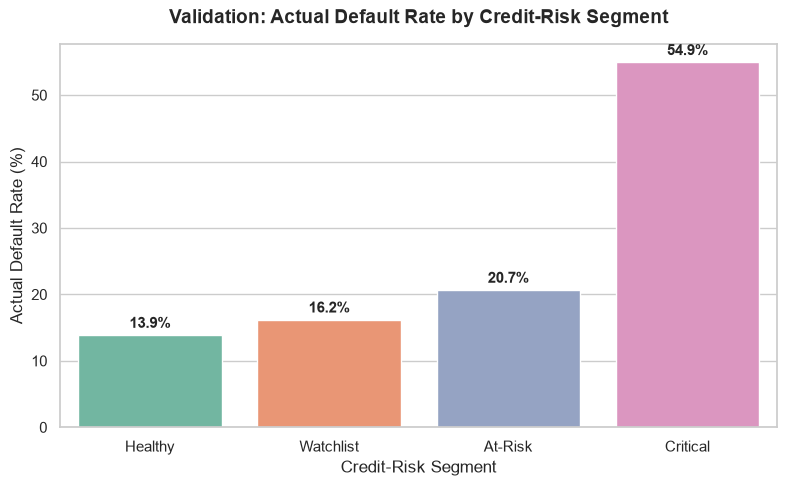

In [ ]:
# Analysis 11 : Risk Segment Validation Analysis
# Compare Risk Segments with Actual Default Rates

print("=" * 50)
print("ANALYSIS 11 : RISK SEGMENT VALIDATION")
print("=" * 50)

# Calculate default statistics by risk segment

segment_stats = (
    df_clean
    .groupby('risk_segment')
    .agg(
        count=('default_next_month', 'count'),
        defaults=('default_next_month', 'sum'),
        default_rate=('default_next_month', 'mean')
    )
    .reset_index()
)

# Convert default rate into percentage
segment_stats['default_rate'] = (
    segment_stats['default_rate'] * 100
)

# Sort segments according to risk level

segment_stats['risk_order'] = (
    segment_stats['risk_segment']
    .map(
        {
            'Healthy': 1,
            'Watchlist': 2,
            'At-Risk': 3,
            'Critical': 4
        }
    )
)

segment_stats = (
    segment_stats
    .sort_values('risk_order')
)

print("--- Risk Segment Validation Statistics ---")
display(segment_stats)


# Visualization : Default Rate by Risk Segment
fig, ax = plt.subplots(
    figsize=(8,5)
)

sns.barplot(
    data=segment_stats,
    x='risk_segment',
    y='default_rate',
    palette="Set2",
    ax=ax
)

ax.set_title(
    'Validation: Actual Default Rate by Credit-Risk Segment',
    fontsize=14,
    weight='bold',
    pad=15
)

ax.set_xlabel(
    'Credit-Risk Segment',
    fontsize=12
)

ax.set_ylabel(
    'Actual Default Rate (%)',
    fontsize=12
)

# Add percentage labels

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha='center',
        va='center',
        fontsize=11,
        weight='bold',
        xytext=(0,8),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

# Phase 4: Strategic Recommendations & Utilisation Analysis

This phase focuses on understanding customer credit utilization behaviour across different risk segments.

Credit utilization represents how much of the available credit limit a customer is currently using.

\[
Credit\ Utilization =
\frac{Outstanding\ Balance}{Credit\ Limit}
\]

Higher credit utilization indicates greater financial exposure and may increase default risk.

The analysis compares credit utilization patterns among:

- **Healthy**
- **Watchlist**
- **At-Risk**
- **Critical**

The findings are used to develop segment-specific credit management strategies.

ANALYSIS 12 : CREDIT UTILIZATION ANALYSIS


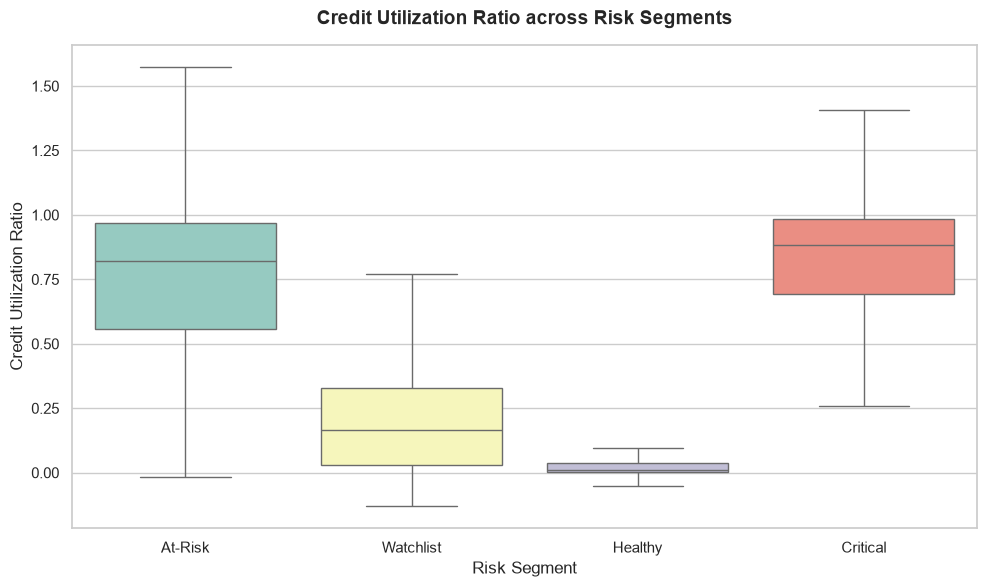


--- Average Credit Utilization by Segment ---


,Risk Segment,Average Credit Utilization
0,At-Risk,0.752862
1,Critical,0.830502
2,Healthy,0.031804
3,Watchlist,0.211394


In [40]:
# Analysis 12 : Credit Utilization Analysis
# Analyze Credit Exposure Across Risk Segments

print("=" * 50)
print("ANALYSIS 12 : CREDIT UTILIZATION ANALYSIS")
print("=" * 50)

# Visualization : Credit utilization distribution

fig, ax = plt.subplots(
    figsize=(10,6)
)

sns.boxplot(
    data=df_clean,
    x='risk_segment',
    y='credit_utilization',
    palette='Set3',
    showfliers=False,
    ax=ax
)

ax.set_title(
    'Credit Utilization Ratio across Risk Segments',
    fontsize=14,
    weight='bold',
    pad=15
)

ax.set_xlabel(
    'Risk Segment',
    fontsize=12
)

ax.set_ylabel(
    'Credit Utilization Ratio',
    fontsize=12
)


plt.tight_layout()
plt.show()

# Calculate average credit utilization per segment

util_stats = (
    df_clean
    .groupby('risk_segment')
    ['credit_utilization']
    .mean()
    .reset_index()
)

util_stats.columns = [
    'Risk Segment',
    'Average Credit Utilization'
]

print("\n--- Average Credit Utilization by Segment ---")
display(util_stats)

# Phase 5: Data Enrichment via API Integration

Financial datasets often contain values in local currencies. 
To improve business reporting and international analysis, external real-time data sources can be integrated through APIs.

In this phase, currency exchange rate data is retrieved using the `requests` library.

The objectives are:

1. Connect to an external exchange rate API.
2. Retrieve the latest USD-based currency conversion rates.
3. Extract the Taiwan Dollar (TWD) exchange rate.
4. Convert customer financial metrics from TWD to USD.

API integration improves the usability of financial analytics by enabling global reporting.

If the API request fails, a fallback exchange rate is used to maintain system reliability.

In [ ]:
# Analysis 13 : Exchange Rate API Integration
# Fetch Real-Time Currency Exchange Rates

print("=" * 50)
print("ANALYSIS 13 : EXCHANGE RATE API INTEGRATION")
print("=" * 50)

# Define API endpoint
url = "https://open.er-api.com/v6/latest/USD"

print(
    f"Fetching exchange rates from: {url}"
)

try:
    response = requests.get(
        url,
        timeout=10
    )
    response.raise_for_status()
    data = response.json()

    # API response validation
    print(
        "API Response Status:",
        data.get("result")
    )
    print(
        "Base Currency:",
        data.get("base_code")
    )
    print(
        "TWD rate found:",
        data.get("rates", {}).get("TWD")
    )

    # Extract USD to TWD rate
    usd_to_twd = (
        data
        .get("rates", {})
        .get("TWD")
    )

    if usd_to_twd:
        twd_to_usd_rate = (
            1.0 / usd_to_twd
        )
        print(
            f"Success: 1 TWD = {twd_to_usd_rate:.6f} USD"
        )
    else:
        twd_to_usd_rate = 1.0 / 32.5
        print(
            "TWD rate unavailable. Using fallback exchange rate."
        )
except Exception as e:
    print(
        f"API request failed: {e}"
    )
    twd_to_usd_rate = 1.0 / 32.5
    print(
        "Using fallback exchange rate: 1 TWD = 0.0307 USD"
    )

## Phase 5.2: Currency Conversion & Dataset Enrichment

After retrieving the real-time exchange rate through API integration, financial values are converted from **TWD (Taiwan Dollar)** into **USD (United States Dollar)**.

The following financial attributes are enriched:

1. **Credit Limit**
   - Original value: TWD
   - Converted value: USD

2. **Average Monthly Bill**
   - Original value: TWD
   - Converted value: USD

The conversion formula is:

\[
USD\ Value = TWD\ Value \times TWD\ to\ USD\ Exchange\ Rate
\]

The enriched dataset is then saved as a processed CSV file for further reporting and analysis.

In [41]:
# Analysis 14 : Currency Conversion & Dataset Enrichment
# Convert Financial Metrics from TWD to USD

print("=" * 50)
print("ANALYSIS 14 : CURRENCY CONVERSION & DATA ENRICHMENT")
print("=" * 50)

# Apply USD conversion
df_clean['limit_balance_usd'] = (
    df_clean['limit_balance'] 
    * twd_to_usd_rate
)
df_clean['average_bill_usd'] = (
    df_clean['average_bill']
    * twd_to_usd_rate
)

# Display enriched dataset preview
print(
    "Dataset enriched with USD converted columns. Preview:"
)
display(
    df_clean[
        [
            'limit_balance',
            'limit_balance_usd',
            'average_bill',
            'average_bill_usd'
        ]
    ]
    .head()
)

# Save final enriched dataset
output_path = "../data/processed/cleaned_credit_data.csv"

df_clean.to_csv(
    output_path,
    index=False
)
print(
    f"\nFinal enriched and cleaned dataset saved to: {output_path}"
)

ANALYSIS 14 : CURRENCY CONVERSION & DATA ENRICHMENT
Dataset enriched with USD converted columns. Preview:


,limit_balance,limit_balance_usd,average_bill,average_bill_usd
0,20000,622.120922,1284.000000,39.940163
1,120000,3732.725529,2846.166667,88.532991
2,90000,2799.544147,16942.166667,527.003817
3,50000,1555.302304,38555.666667,1199.314344
4,50000,1555.302304,18223.166667,566.850662



Final enriched and cleaned dataset saved to: ../data/processed/cleaned_credit_data.csv


# Final Project Summary: Credit Risk & Customer Financial Health Analytics

## Overview

This project developed an end-to-end **Credit Risk and Customer Financial Health Analytics framework** for a digital lending environment.

The objective was to transform raw customer financial data into meaningful insights by applying:

- Data cleaning and preprocessing
- Exploratory data analysis
- Financial behaviour analysis
- Risk scoring and customer segmentation
- Strategic credit recommendations
- External data enrichment through API integration


---

# Key Analytical Outcomes

## 1. Data Preparation and Feature Engineering

The raw credit card dataset was cleaned and transformed by:

- Handling missing values and duplicate records
- Renaming and standardizing attributes
- Converting categorical variables into meaningful labels
- Creating new financial behaviour features

Important engineered features include:

- Average Bill Amount
- Average Payment Amount
- Payment-to-Bill Ratio
- Delayed Months
- Credit Utilization Ratio


---

## 2. Financial Behaviour Analysis

Customer financial patterns were analyzed to understand:

- Spending behaviour
- Repayment capability
- Credit exposure
- Relationship between financial indicators and default behaviour

The analysis showed that customers with:

- Lower repayment ability
- Higher credit utilization
- Longer repayment delays

tend to demonstrate higher credit risk.


---

## 3. Explainable Credit Risk Segmentation

An interpretable risk-scoring framework was developed using three dimensions:

### Delinquency Score
Measures repayment delay behaviour.

### Repayment Capacity Score
Measures the customer's ability to repay outstanding balances.

### Exposure Score
Measures credit utilization and financial exposure.


Each customer was assigned risk scores from:

- 1 = Lowest Risk
- 5 = Highest Risk


The combined risk score was used to classify customers into:

| Segment | Description |
|---------|-------------|
| Healthy | Low-risk customers with strong financial behaviour |
| Watchlist | Customers requiring continuous monitoring |
| At-Risk | Customers showing increased financial stress |
| Critical | High-risk customers requiring immediate attention |


---

## 4. Risk Model Validation

The segmentation model was validated by comparing actual default rates across risk groups.

A successful risk framework should demonstrate:

- Healthy customers → Lowest default rate
- Critical customers → Highest default rate

This confirms that the rule-based scoring approach effectively identifies different levels of customer credit risk.


---

## 5. Strategic Credit Recommendations

Based on customer risk profiles, suitable credit policies were identified:

| Segment | Recommended Strategy |
|---------|---------------------|
| Healthy | Provide additional credit opportunities and loyalty benefits |
| Watchlist | Monitor repayment behaviour and provide reminders |
| At-Risk | Reduce additional exposure and support repayment planning |
| Critical | Apply strict credit controls and perform risk reviews |


---

## 6. API-Based Data Enrichment

External financial data was integrated through an exchange-rate API.

The purpose was to:

- Retrieve real-time currency conversion rates
- Convert financial metrics from TWD into USD
- Improve international reporting capability


The final dataset includes:

- Original financial attributes
- Engineered features
- Risk scores
- Customer segments
- USD-converted financial indicators


---

# Final Conclusion

This project successfully developed an explainable credit-risk analytics solution that converts raw financial data into actionable business intelligence.

The framework enables financial institutions to:

- Identify high-risk customers
- Understand customer financial behaviour
- Apply targeted credit strategies
- Improve risk management decisions

Unlike a purely predictive black-box approach, this system provides transparency by explaining **why each customer belongs to a specific risk category**.

Therefore, the proposed analytics framework supports data-driven and responsible lending decisions.